# Surrogate Models for Unit Operations: Pump Example

This notebook demonstrates how to create and use neural network surrogate models
for unit operations within the difflow framework.

**Topics covered:**
1. Physics-based pump model (ground truth)
2. Static surrogate pump using neural networks
3. Training the static surrogate
4. Dynamic surrogate pump with startup transients
5. Training the dynamic surrogate
6. Using surrogates in flowsheets
7. Gradient-based optimization through surrogates

In [1]:
import os
os.environ['JAX_PLATFORM_NAME'] = 'cpu'

import jax
import jax.numpy as jnp
from jax import random, grad, vmap, jit
import matplotlib.pyplot as plt

# Configure JAX
jax.config.update("jax_enable_x64", True)

# Import difflow
from difflow.streams import make_stream, get_flows, total_flow
from difflow.dynamic import (
    DynamicUnitBase,
    StateSpec,
    StateVar,
    StateVector,
    integrate_unit,
    integrate,
    pressure_state,
)

print(f"JAX version: {jax.__version__}")

W0000 00:00:1765976339.928264 13766292 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1765976339.937463 13766292 service.cc:145] XLA service 0x6000027b0f00 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765976339.937472 13766292 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1765976339.938484 13766292 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1765976339.938490 13766292 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M4 Pro


JAX version: 0.8.1


## 1. Physics-Based Pump Model (Ground Truth)

First, let's create a physics-based pump model that we'll use to generate training data.

A centrifugal pump can be characterized by:
- **Head-flow curve**: $H = H_0 - a Q^2$ (parabolic)
- **Efficiency curve**: $\eta = \eta_{max} \cdot (1 - b(Q - Q_{opt})^2)$
- **Power**: $P = \rho g Q H / \eta$
- **Pressure rise**: $\Delta P = \rho g H$

For simplicity, we'll work with molar flow rates and assume constant density.

In [2]:
class PhysicsPump:
    """Physics-based centrifugal pump model.
    
    This serves as our 'ground truth' for generating training data.
    """
    
    def __init__(
        self,
        H0: float = 50.0,      # Shutoff head (m)
        a: float = 0.01,       # Head curve coefficient (m/(mol/s)^2)
        eta_max: float = 0.75, # Maximum efficiency
        Q_opt: float = 50.0,   # Optimal flow rate (mol/s)
        b: float = 0.0004,     # Efficiency curve width
        rho: float = 1000.0,   # Fluid density (kg/m³)
        MW: float = 0.018,     # Molecular weight (kg/mol) - water
    ):
        self.H0 = H0
        self.a = a
        self.eta_max = eta_max
        self.Q_opt = Q_opt
        self.b = b
        self.rho = rho
        self.MW = MW
        self.g = 9.81  # m/s²
    
    def head(self, Q: jnp.ndarray) -> jnp.ndarray:
        """Pump head (m) as function of volumetric flow."""
        return self.H0 - self.a * Q**2
    
    def efficiency(self, Q: jnp.ndarray) -> jnp.ndarray:
        """Pump efficiency as function of flow."""
        eta = self.eta_max * (1 - self.b * (Q - self.Q_opt)**2)
        return jnp.clip(eta, 0.1, self.eta_max)  # Minimum efficiency
    
    def __call__(self, inlet, speed_fraction: float = 1.0):
        """Process inlet stream through pump.
        
        Args:
            inlet: Input stream dict with F_*, T, P
            speed_fraction: Pump speed as fraction of rated (0-1)
            
        Returns:
            (outlet_stream, info_dict)
        """
        # Get molar flow and convert to volumetric
        F_total = total_flow(inlet)
        Q = F_total * self.MW / self.rho  # m³/s
        
        # Apply affinity laws for speed variation
        # Q ∝ N, H ∝ N², P ∝ N³
        Q_eff = Q / speed_fraction  # Equivalent flow at rated speed
        
        # Calculate head and efficiency at rated speed
        H_rated = self.head(Q_eff)
        eta = self.efficiency(Q_eff)
        
        # Apply affinity laws
        H = H_rated * speed_fraction**2
        
        # Pressure rise
        dP = self.rho * self.g * H
        P_out = inlet['P'] + dP
        
        # Power consumption
        power = self.rho * self.g * Q * H / (eta + 1e-10)
        
        # Temperature rise from inefficiency (simplified)
        # Q_waste = power * (1 - eta)
        # dT = Q_waste / (F_total * Cp)
        Cp = 75.0  # J/mol/K (water)
        dT = power * (1 - eta) / (F_total * Cp + 1e-10)
        T_out = inlet['T'] + dT
        
        # Create outlet stream (same composition, new T and P)
        outlet_flows = get_flows(inlet)
        outlet = make_stream(outlet_flows, T_out, P_out)
        
        info = {
            'head': H,
            'efficiency': eta,
            'power': power,
            'dP': dP,
            'dT': dT,
        }
        
        return outlet, info


# Create physics pump
physics_pump = PhysicsPump()

# Test it
inlet = make_stream({'water': 50.0}, T=300.0, P=101325.0)
outlet, info = physics_pump(inlet, speed_fraction=1.0)

print("Physics Pump Test:")
print(f"  Inlet:  F={total_flow(inlet):.1f} mol/s, T={inlet['T']:.1f} K, P={inlet['P']/1000:.1f} kPa")
print(f"  Outlet: F={total_flow(outlet):.1f} mol/s, T={outlet['T']:.2f} K, P={outlet['P']/1000:.1f} kPa")
print(f"  Head: {info['head']:.2f} m")
print(f"  Efficiency: {info['efficiency']*100:.1f}%")
print(f"  Power: {info['power']:.1f} W")

Physics Pump Test:
  Inlet:  F=50.0 mol/s, T=300.0 K, P=101.3 kPa
  Outlet: F=50.0 mol/s, T=301.06 K, P=591.8 kPa
  Head: 50.00 m
  Efficiency: 10.0%
  Power: 4414.5 W


### Visualize Pump Curves

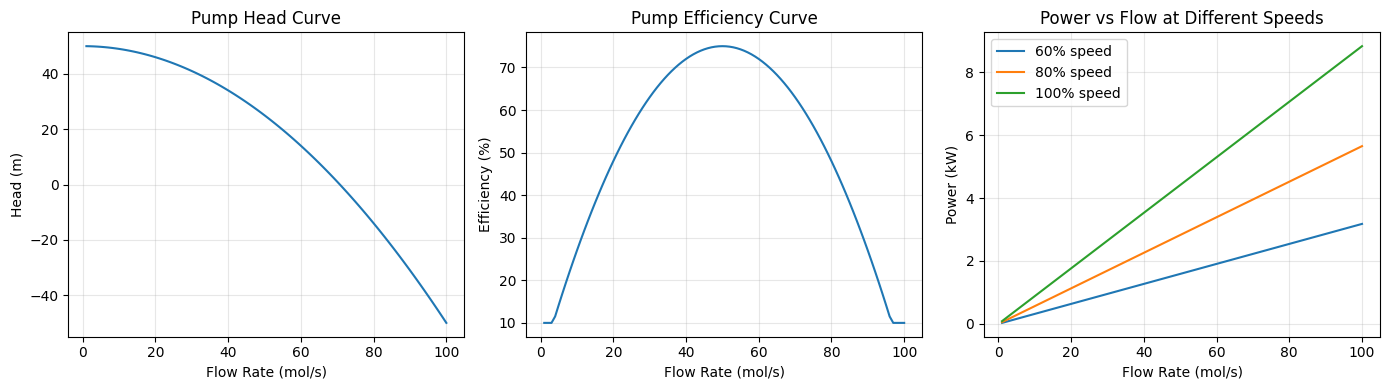

In [3]:
# Generate pump curves
Q_range = jnp.linspace(1, 100, 100)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Head curve
H_curve = vmap(physics_pump.head)(Q_range)
axes[0].plot(Q_range, H_curve)
axes[0].set_xlabel('Flow Rate (mol/s)')
axes[0].set_ylabel('Head (m)')
axes[0].set_title('Pump Head Curve')
axes[0].grid(True, alpha=0.3)

# Efficiency curve
eta_curve = vmap(physics_pump.efficiency)(Q_range)
axes[1].plot(Q_range, eta_curve * 100)
axes[1].set_xlabel('Flow Rate (mol/s)')
axes[1].set_ylabel('Efficiency (%)')
axes[1].set_title('Pump Efficiency Curve')
axes[1].grid(True, alpha=0.3)

# Power curve at different speeds
for speed in [0.6, 0.8, 1.0]:
    powers = []
    for Q in Q_range:
        inlet = make_stream({'water': float(Q)}, T=300.0, P=101325.0)
        _, info = physics_pump(inlet, speed_fraction=speed)
        powers.append(info['power'])
    axes[2].plot(Q_range, jnp.array(powers) / 1000, label=f'{speed*100:.0f}% speed')

axes[2].set_xlabel('Flow Rate (mol/s)')
axes[2].set_ylabel('Power (kW)')
axes[2].set_title('Power vs Flow at Different Speeds')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Static Surrogate Pump Model

Now let's create a neural network surrogate that learns the pump behavior.

The surrogate will:
- **Input**: Flow rate, inlet temperature, inlet pressure, pump speed
- **Output**: Pressure rise, temperature rise, power consumption

In [4]:
def init_mlp(key, layer_sizes):
    """Initialize MLP parameters.
    
    Args:
        key: JAX random key
        layer_sizes: List of layer sizes [input, hidden1, ..., output]
    
    Returns:
        List of (weights, biases) tuples
    """
    params = []
    for i in range(len(layer_sizes) - 1):
        key, subkey = random.split(key)
        in_size, out_size = layer_sizes[i], layer_sizes[i + 1]
        # Xavier initialization
        scale = jnp.sqrt(2.0 / (in_size + out_size))
        w = random.normal(subkey, (out_size, in_size)) * scale
        b = jnp.zeros(out_size)
        params.append((w, b))
    return params


def mlp_forward(params, x):
    """Forward pass through MLP.
    
    Args:
        params: List of (weights, biases)
        x: Input array
    
    Returns:
        Output array
    """
    for i, (w, b) in enumerate(params):
        x = w @ x + b
        # ReLU activation except for last layer
        if i < len(params) - 1:
            x = jax.nn.relu(x)
    return x


class SurrogatePump:
    """Neural network surrogate for pump model.
    
    Input features (normalized):
        - Flow rate (mol/s)
        - Inlet temperature (K) 
        - Inlet pressure (Pa)
        - Pump speed fraction
    
    Output predictions:
        - Pressure rise (Pa)
        - Temperature rise (K)
        - Power consumption (W)
    """
    
    def __init__(self, nn_params, input_scale, output_scale):
        """Initialize surrogate pump.
        
        Args:
            nn_params: Neural network parameters
            input_scale: (mean, std) for input normalization
            output_scale: (mean, std) for output denormalization
        """
        self.nn_params = nn_params
        self.input_mean, self.input_std = input_scale
        self.output_mean, self.output_std = output_scale
    
    def predict_raw(self, features):
        """Raw NN prediction (normalized in/out)."""
        x_norm = (features - self.input_mean) / (self.input_std + 1e-8)
        y_norm = mlp_forward(self.nn_params, x_norm)
        return y_norm * self.output_std + self.output_mean
    
    def __call__(self, inlet, speed_fraction: float = 1.0):
        """Process inlet stream through surrogate pump.
        
        Follows the same interface as PhysicsPump.
        """
        # Extract features
        F_total = total_flow(inlet)
        features = jnp.array([
            F_total,
            inlet['T'],
            inlet['P'],
            speed_fraction,
        ])
        
        # Neural network prediction
        outputs = self.predict_raw(features)
        dP, dT, power = outputs[0], outputs[1], outputs[2]
        
        # Ensure physical constraints
        dP = jnp.maximum(dP, 0.0)  # Pressure can only increase
        power = jnp.maximum(power, 0.0)  # Power is positive
        
        # Create outlet stream
        outlet_flows = get_flows(inlet)
        T_out = inlet['T'] + dT
        P_out = inlet['P'] + dP
        outlet = make_stream(outlet_flows, T_out, P_out)
        
        info = {
            'dP': dP,
            'dT': dT,
            'power': power,
        }
        
        return outlet, info


# Initialize network architecture
key = random.PRNGKey(42)
layer_sizes = [4, 32, 32, 3]  # 4 inputs, 2 hidden layers, 3 outputs
nn_params = init_mlp(key, layer_sizes)

print(f"Network architecture: {layer_sizes}")
print(f"Total parameters: {sum(w.size + b.size for w, b in nn_params)}")

Network architecture: [4, 32, 32, 3]
Total parameters: 1315


## 3. Training the Static Surrogate

Generate training data from the physics model and train the neural network.

In [5]:
def generate_training_data(pump, n_samples, key):
    """Generate training data from physics pump.
    
    Returns:
        X: Input features (n_samples, 4)
        Y: Output targets (n_samples, 3)
    """
    keys = random.split(key, 4)
    
    # Sample operating conditions
    flows = random.uniform(keys[0], (n_samples,), minval=5.0, maxval=100.0)
    temps = random.uniform(keys[1], (n_samples,), minval=280.0, maxval=350.0)
    pressures = random.uniform(keys[2], (n_samples,), minval=50000.0, maxval=200000.0)
    speeds = random.uniform(keys[3], (n_samples,), minval=0.5, maxval=1.0)
    
    X = []
    Y = []
    
    for i in range(n_samples):
        inlet = make_stream({'water': float(flows[i])}, T=float(temps[i]), P=float(pressures[i]))
        outlet, info = pump(inlet, speed_fraction=float(speeds[i]))
        
        x = [flows[i], temps[i], pressures[i], speeds[i]]
        y = [info['dP'], info['dT'], info['power']]
        
        X.append(x)
        Y.append(y)
    
    return jnp.array(X), jnp.array(Y)


# Generate data
n_train = 1000
n_test = 200

key, subkey = random.split(key)
X_train, Y_train = generate_training_data(physics_pump, n_train, subkey)

key, subkey = random.split(key)
X_test, Y_test = generate_training_data(physics_pump, n_test, subkey)

# Compute normalization statistics
input_mean = jnp.mean(X_train, axis=0)
input_std = jnp.std(X_train, axis=0)
output_mean = jnp.mean(Y_train, axis=0)
output_std = jnp.std(Y_train, axis=0)

print(f"Training samples: {n_train}")
print(f"Test samples: {n_test}")
print(f"\nInput statistics:")
print(f"  Flow:     mean={input_mean[0]:.1f}, std={input_std[0]:.1f}")
print(f"  Temp:     mean={input_mean[1]:.1f}, std={input_std[1]:.1f}")
print(f"  Pressure: mean={input_mean[2]:.0f}, std={input_std[2]:.0f}")
print(f"  Speed:    mean={input_mean[3]:.2f}, std={input_std[3]:.2f}")
print(f"\nOutput statistics:")
print(f"  dP:    mean={output_mean[0]:.0f} Pa, std={output_std[0]:.0f}")
print(f"  dT:    mean={output_mean[1]:.4f} K, std={output_std[1]:.4f}")
print(f"  Power: mean={output_mean[2]:.0f} W, std={output_std[2]:.0f}")

Training samples: 1000
Test samples: 200

Input statistics:
  Flow:     mean=52.9, std=27.4
  Temp:     mean=315.3, std=19.8
  Pressure: mean=126086, std=42913
  Speed:    mean=0.74, std=0.14

Output statistics:
  dP:    mean=281523 Pa, std=105337
  dT:    mean=0.6081 K, std=0.2275
  Power: mean=2662 W, std=1758


In [6]:
def loss_fn(params, X_batch, Y_batch, input_scale, output_scale):
    """Mean squared error loss."""
    input_mean, input_std = input_scale
    output_mean, output_std = output_scale
    
    def predict(x):
        x_norm = (x - input_mean) / (input_std + 1e-8)
        y_norm = mlp_forward(params, x_norm)
        return y_norm * output_std + output_mean
    
    Y_pred = vmap(predict)(X_batch)
    
    # Normalize loss by output scale for balanced gradients
    errors = (Y_pred - Y_batch) / (output_std + 1e-8)
    return jnp.mean(errors**2)


def update_step(params, X_batch, Y_batch, learning_rate, input_scale, output_scale):
    """Single SGD update step."""
    loss, grads = jax.value_and_grad(loss_fn)(params, X_batch, Y_batch, input_scale, output_scale)
    
    # Update parameters
    new_params = []
    for (w, b), (dw, db) in zip(params, grads):
        new_params.append((
            w - learning_rate * dw,
            b - learning_rate * db,
        ))
    
    return new_params, loss


# Training loop
n_epochs = 500
batch_size = 64
learning_rate = 0.01

input_scale = (input_mean, input_std)
output_scale = (output_mean, output_std)

train_losses = []
test_losses = []

for epoch in range(n_epochs):
    # Shuffle training data
    key, subkey = random.split(key)
    perm = random.permutation(subkey, n_train)
    X_shuffled = X_train[perm]
    Y_shuffled = Y_train[perm]
    
    # Mini-batch updates
    epoch_loss = 0.0
    n_batches = n_train // batch_size
    
    for i in range(n_batches):
        X_batch = X_shuffled[i*batch_size:(i+1)*batch_size]
        Y_batch = Y_shuffled[i*batch_size:(i+1)*batch_size]
        nn_params, loss = update_step(nn_params, X_batch, Y_batch, learning_rate, input_scale, output_scale)
        epoch_loss += loss
    
    epoch_loss /= n_batches
    train_losses.append(float(epoch_loss))
    
    # Evaluate on test set
    test_loss = loss_fn(nn_params, X_test, Y_test, input_scale, output_scale)
    test_losses.append(float(test_loss))
    
    # Learning rate decay
    if epoch > 0 and epoch % 100 == 0:
        learning_rate *= 0.5
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d}: train_loss={epoch_loss:.6f}, test_loss={test_loss:.6f}")

print(f"\nFinal: train_loss={train_losses[-1]:.6f}, test_loss={test_losses[-1]:.6f}")

Epoch   0: train_loss=0.991694, test_loss=1.007958


Epoch  50: train_loss=0.011082, test_loss=0.012013


Epoch 100: train_loss=0.006386, test_loss=0.007307


Epoch 150: train_loss=0.005718, test_loss=0.006395


Epoch 200: train_loss=0.005186, test_loss=0.005775


...

Epoch 300: train_loss=0.004779, test_loss=0.005301


Epoch 350: train_loss=0.004725, test_loss=0.005202


Epoch 400: train_loss=0.004546, test_loss=0.005106


Epoch 450: train_loss=0.004556, test_loss=0.005060



Final: train_loss=0.004518, test_loss=0.005017


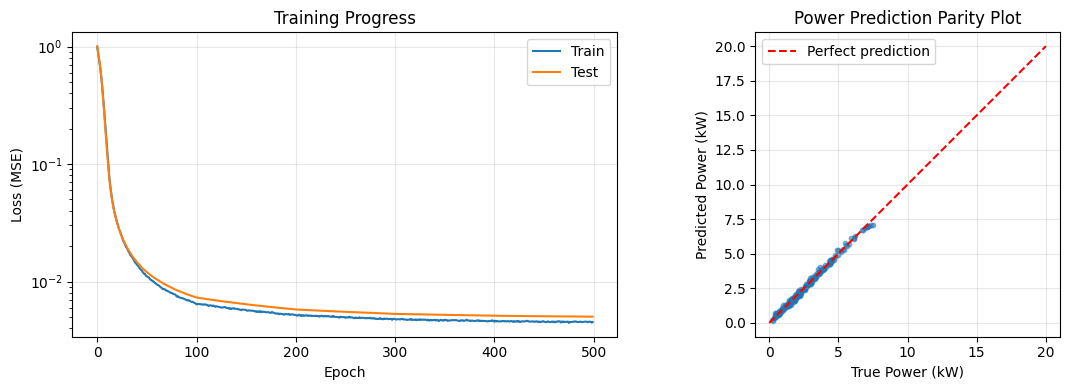

dP: R² = 0.9956
dT: R² = 0.9957
Power: R² = 0.9946


In [7]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(train_losses, label='Train')
axes[0].semilogy(test_losses, label='Test')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Training Progress')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Parity plot for power prediction
surrogate_pump = SurrogatePump(nn_params, input_scale, output_scale)

Y_pred_test = []
for i in range(n_test):
    inlet = make_stream({'water': float(X_test[i, 0])}, T=float(X_test[i, 1]), P=float(X_test[i, 2]))
    _, info = surrogate_pump(inlet, speed_fraction=float(X_test[i, 3]))
    Y_pred_test.append([info['dP'], info['dT'], info['power']])
Y_pred_test = jnp.array(Y_pred_test)

axes[1].scatter(Y_test[:, 2]/1000, Y_pred_test[:, 2]/1000, alpha=0.5, s=10)
axes[1].plot([0, 20], [0, 20], 'r--', label='Perfect prediction')
axes[1].set_xlabel('True Power (kW)')
axes[1].set_ylabel('Predicted Power (kW)')
axes[1].set_title('Power Prediction Parity Plot')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

# Compute R² scores
for i, name in enumerate(['dP', 'dT', 'Power']):
    ss_res = jnp.sum((Y_test[:, i] - Y_pred_test[:, i])**2)
    ss_tot = jnp.sum((Y_test[:, i] - jnp.mean(Y_test[:, i]))**2)
    r2 = 1 - ss_res / ss_tot
    print(f"{name}: R² = {r2:.4f}")

### Compare Physics and Surrogate Models

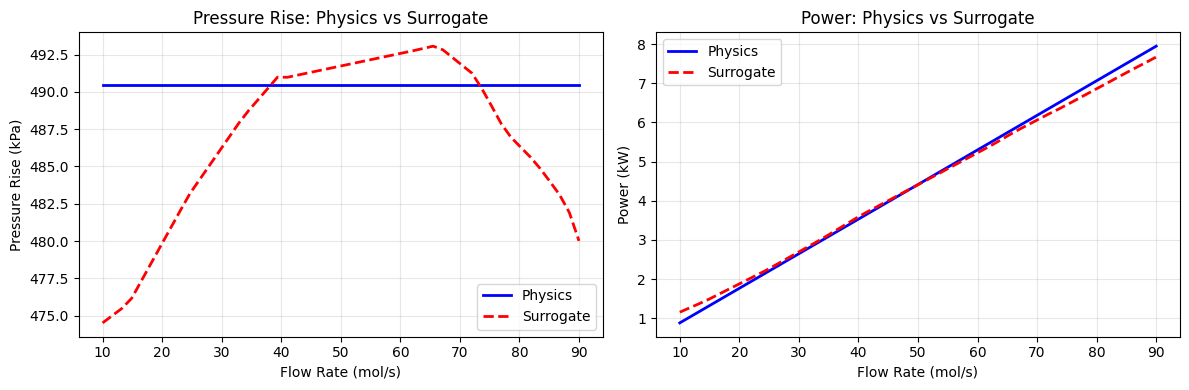

In [8]:
# Compare predictions across flow range
flow_range = jnp.linspace(10, 90, 50)
T_fixed, P_fixed, speed_fixed = 300.0, 101325.0, 1.0

physics_results = {'dP': [], 'power': []}
surrogate_results = {'dP': [], 'power': []}

for F in flow_range:
    inlet = make_stream({'water': float(F)}, T=T_fixed, P=P_fixed)
    
    _, info_phys = physics_pump(inlet, speed_fraction=speed_fixed)
    _, info_surr = surrogate_pump(inlet, speed_fraction=speed_fixed)
    
    physics_results['dP'].append(info_phys['dP'])
    physics_results['power'].append(info_phys['power'])
    surrogate_results['dP'].append(info_surr['dP'])
    surrogate_results['power'].append(info_surr['power'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(flow_range, jnp.array(physics_results['dP'])/1000, 'b-', label='Physics', linewidth=2)
axes[0].plot(flow_range, jnp.array(surrogate_results['dP'])/1000, 'r--', label='Surrogate', linewidth=2)
axes[0].set_xlabel('Flow Rate (mol/s)')
axes[0].set_ylabel('Pressure Rise (kPa)')
axes[0].set_title('Pressure Rise: Physics vs Surrogate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(flow_range, jnp.array(physics_results['power'])/1000, 'b-', label='Physics', linewidth=2)
axes[1].plot(flow_range, jnp.array(surrogate_results['power'])/1000, 'r--', label='Surrogate', linewidth=2)
axes[1].set_xlabel('Flow Rate (mol/s)')
axes[1].set_ylabel('Power (kW)')
axes[1].set_title('Power: Physics vs Surrogate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Dynamic Surrogate Pump Model

Now let's create a dynamic pump model that can simulate startup transients.

The dynamic pump has state variables:
- **omega**: Rotational speed (rad/s)
- **P_discharge**: Discharge pressure (Pa)

Dynamics:
- Motor inertia: $J \frac{d\omega}{dt} = \tau_{motor} - \tau_{load}$
- Pressure dynamics: $\tau_P \frac{dP}{dt} = P_{ss}(\omega, Q) - P$

In [9]:
class DynamicSurrogatePump(DynamicUnitBase):
    """Dynamic pump with neural network steady-state surrogate.
    
    State variables:
        - omega: Rotational speed (rad/s)
        - P_discharge: Discharge pressure (Pa)
    
    The neural network predicts steady-state behavior, while
    the dynamics capture motor inertia and pressure lag.
    """
    
    def __init__(
        self,
        nn_params,
        input_scale,
        output_scale,
        omega_rated: float = 300.0,  # Rated speed (rad/s)
        J: float = 0.5,              # Motor inertia (kg·m²)
        tau_P: float = 0.5,          # Pressure time constant (s)
        K_motor: float = 10.0,       # Motor torque constant
        name: str | None = None,
    ):
        self.nn_params = nn_params
        self.input_mean, self.input_std = input_scale
        self.output_mean, self.output_std = output_scale
        self.omega_rated = omega_rated
        self.J = J
        self.tau_P = tau_P
        self.K_motor = K_motor
        
        super().__init__(name=name)
    
    def _build_state_spec(self) -> StateSpec:
        """Define state variables."""
        return StateSpec([
            StateVar(
                name="omega",
                category="generic",
                units="rad/s",
                description="Rotational speed",
                bounds=(0.0, None),
                scale=self.omega_rated,
                initial_value=0.0,
            ),
            StateVar(
                name="P_discharge",
                category="pressure",
                units="Pa",
                description="Discharge pressure",
                bounds=(0.0, None),
                scale=200000.0,
                initial_value=101325.0,
            ),
        ])
    
    def _predict_steady_state(self, F_total, T_in, P_in, speed_frac):
        """Neural network prediction of steady-state."""
        features = jnp.array([F_total, T_in, P_in, speed_frac])
        x_norm = (features - self.input_mean) / (self.input_std + 1e-8)
        y_norm = mlp_forward(self.nn_params, x_norm)
        outputs = y_norm * self.output_std + self.output_mean
        return outputs  # [dP, dT, power]
    
    def _derivatives(
        self,
        t: jnp.ndarray,
        state: StateVector,
        inputs: dict,
    ) -> jnp.ndarray:
        """Compute state derivatives."""
        omega = state["omega"]
        P_discharge = state["P_discharge"]
        
        # Get inlet conditions
        inlet = inputs.get("inlet") or list(inputs.values())[0]
        F_total = total_flow(inlet)
        T_in = inlet["T"]
        P_in = inlet["P"]
        
        # Speed setpoint from params (normalized)
        omega_sp = self.params.get("omega_setpoint", self.omega_rated)
        speed_frac = omega / self.omega_rated
        
        # Neural network predicts steady-state at current speed
        ss_outputs = self._predict_steady_state(F_total, T_in, P_in, speed_frac)
        dP_ss = jnp.maximum(ss_outputs[0], 0.0)
        power_ss = jnp.maximum(ss_outputs[2], 0.0)
        
        # Target discharge pressure
        P_target = P_in + dP_ss
        
        # Motor dynamics: J * d(omega)/dt = tau_motor - tau_load
        # Simplified: tau_motor proportional to error from setpoint
        # tau_load proportional to power / omega
        tau_motor = self.K_motor * (omega_sp - omega)
        tau_load = power_ss / (omega + 1e-6)
        d_omega = (tau_motor - tau_load) / self.J
        
        # Pressure dynamics: first-order lag
        d_P = (P_target - P_discharge) / self.tau_P
        
        return jnp.array([d_omega, d_P])
    
    def _outputs(
        self,
        t: jnp.ndarray,
        state: StateVector,
        inputs: dict,
    ) -> dict:
        """Compute outlet stream from state."""
        omega = state["omega"]
        P_discharge = state["P_discharge"]
        
        inlet = inputs.get("inlet") or list(inputs.values())[0]
        F_total = total_flow(inlet)
        T_in = inlet["T"]
        P_in = inlet["P"]
        
        speed_frac = omega / self.omega_rated
        
        # Get temperature rise from NN
        ss_outputs = self._predict_steady_state(F_total, T_in, P_in, speed_frac)
        dT = ss_outputs[1]
        
        # Create outlet
        outlet_flows = get_flows(inlet)
        outlet = make_stream(outlet_flows, T_in + dT, P_discharge)
        
        return {"outlet": outlet}
    
    def initial_state(
        self,
        inputs: dict,
        params: dict | None = None,
    ) -> jnp.ndarray:
        """Initialize at rest with inlet pressure."""
        inlet = inputs.get("inlet") or list(inputs.values())[0]
        return jnp.array([0.0, inlet["P"]])  # omega=0, P=P_inlet


# Create dynamic surrogate pump
dynamic_pump = DynamicSurrogatePump(
    nn_params=nn_params,
    input_scale=input_scale,
    output_scale=output_scale,
    name="pump",
)

print(f"Dynamic pump states: {dynamic_pump.state_spec().names}")
print(f"Number of states: {dynamic_pump.state_spec().n_states}")

Dynamic pump states: ['omega', 'P_discharge']
Number of states: 2


### Simulate Pump Startup

In [10]:
# Create inlet stream
inlet = make_stream({'water': 50.0}, T=300.0, P=101325.0)

# Simulate startup
result = integrate_unit(
    dynamic_pump,
    inputs={"inlet": inlet},
    t_span=(0.0, 10.0),  # 10 seconds
    method="RK4",
    n_steps=200,
)

print(f"Initial state: omega={result.trajectory.y[0, 0]:.1f} rad/s, P={result.trajectory.y[0, 1]/1000:.1f} kPa")
print(f"Final state:   omega={result.y_final[0]:.1f} rad/s, P={result.y_final[1]/1000:.1f} kPa")

Initial state: omega=0.0 rad/s, P=101.3 kPa
Final state:   omega=298.5 rad/s, P=589.0 kPa


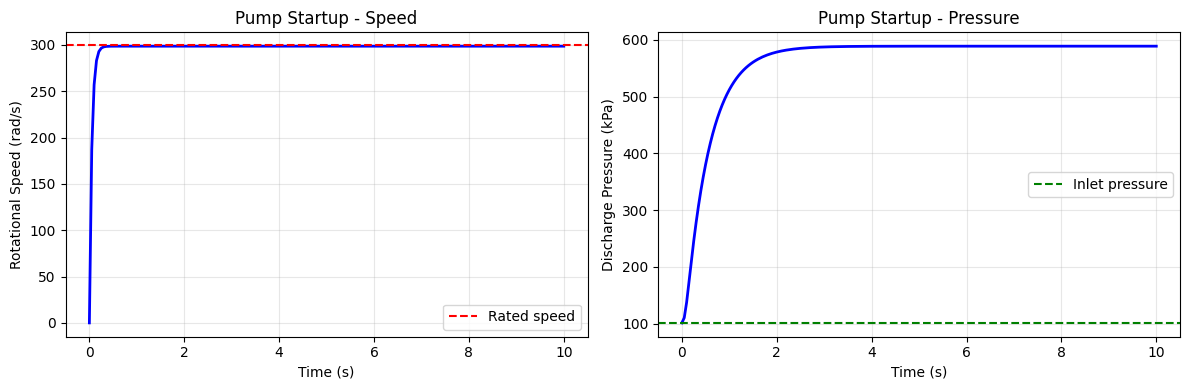

In [11]:
# Plot startup dynamics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Speed profile
axes[0].plot(result.trajectory.t, result.trajectory.y[:, 0], 'b-', linewidth=2)
axes[0].axhline(dynamic_pump.omega_rated, color='r', linestyle='--', label='Rated speed')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Rotational Speed (rad/s)')
axes[0].set_title('Pump Startup - Speed')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Pressure profile
axes[1].plot(result.trajectory.t, result.trajectory.y[:, 1]/1000, 'b-', linewidth=2)
axes[1].axhline(inlet['P']/1000, color='g', linestyle='--', label='Inlet pressure')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Discharge Pressure (kPa)')
axes[1].set_title('Pump Startup - Pressure')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Speed Step Response

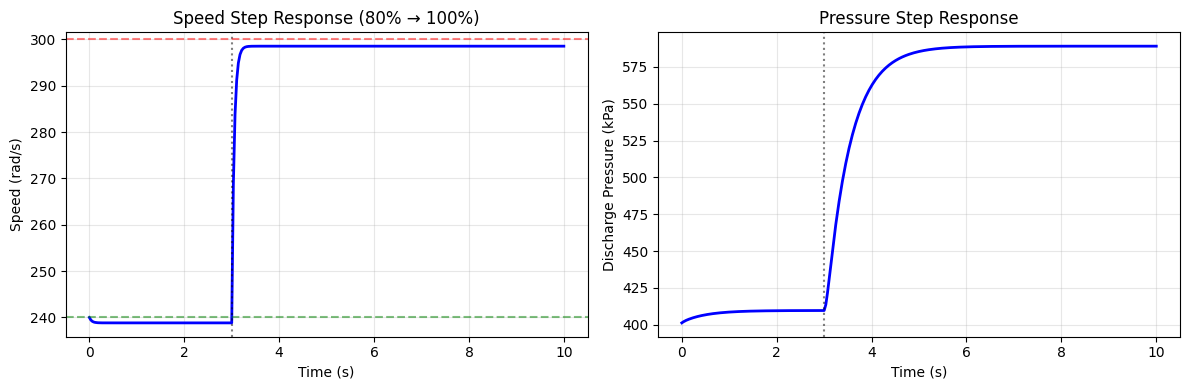

In [12]:
def simulate_speed_step(pump, inlet, omega_initial, omega_final, t_step, t_total):
    """Simulate pump response to speed setpoint change."""
    
    # Phase 1: Run at initial speed until step time
    pump._params["omega_setpoint"] = omega_initial
    y0 = jnp.array([omega_initial, inlet["P"] + 300000.0])  # Start near steady-state
    
    result1 = integrate_unit(
        pump,
        inputs={"inlet": inlet},
        t_span=(0.0, t_step),
        y0=y0,
        method="RK4",
        n_steps=100,
    )
    
    # Phase 2: Step to new speed
    pump._params["omega_setpoint"] = omega_final
    
    result2 = integrate_unit(
        pump,
        inputs={"inlet": inlet},
        t_span=(t_step, t_total),
        y0=result1.y_final,
        method="RK4",
        n_steps=200,
    )
    
    # Combine results
    t_combined = jnp.concatenate([result1.trajectory.t, result2.trajectory.t[1:]])
    y_combined = jnp.vstack([result1.trajectory.y, result2.trajectory.y[1:]])
    
    return t_combined, y_combined, t_step


# Simulate step from 80% to 100% speed
inlet = make_stream({'water': 50.0}, T=300.0, P=101325.0)
omega_initial = 0.8 * dynamic_pump.omega_rated
omega_final = 1.0 * dynamic_pump.omega_rated

t_combined, y_combined, t_step = simulate_speed_step(
    dynamic_pump, inlet, omega_initial, omega_final, t_step=3.0, t_total=10.0
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Speed response
axes[0].plot(t_combined, y_combined[:, 0], 'b-', linewidth=2)
axes[0].axvline(t_step, color='k', linestyle=':', alpha=0.5, label='Step input')
axes[0].axhline(omega_initial, color='g', linestyle='--', alpha=0.5)
axes[0].axhline(omega_final, color='r', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Speed (rad/s)')
axes[0].set_title('Speed Step Response (80% → 100%)')
axes[0].grid(True, alpha=0.3)

# Pressure response
axes[1].plot(t_combined, y_combined[:, 1]/1000, 'b-', linewidth=2)
axes[1].axvline(t_step, color='k', linestyle=':', alpha=0.5, label='Step input')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Discharge Pressure (kPa)')
axes[1].set_title('Pressure Step Response')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Gradient-Based Optimization Through Surrogate

One key advantage of differentiable surrogates is the ability to compute gradients
for optimization. Let's optimize the pump speed to minimize energy while meeting
a pressure target.

In [13]:
# Static optimization: find optimal speed for target pressure
def objective(speed_frac, inlet, target_dP, weight_power=0.001):
    """Objective: minimize power + penalty for missing pressure target."""
    _, info = surrogate_pump(inlet, speed_fraction=speed_frac)
    
    # Pressure error penalty
    pressure_error = (info['dP'] - target_dP)**2 / target_dP**2
    
    # Power cost (normalized)
    power_cost = info['power'] * weight_power
    
    return pressure_error + power_cost


# Target: 300 kPa pressure rise
inlet = make_stream({'water': 50.0}, T=300.0, P=101325.0)
target_dP = 300000.0  # Pa

# Gradient descent optimization
speed = jnp.array(0.8)  # Initial guess
learning_rate = 0.5
history = []

for i in range(50):
    obj_val = objective(speed, inlet, target_dP)
    grad_val = grad(objective)(speed, inlet, target_dP)
    
    _, info = surrogate_pump(inlet, speed_fraction=float(speed))
    history.append({
        'speed': float(speed),
        'objective': float(obj_val),
        'dP': float(info['dP']),
        'power': float(info['power']),
    })
    
    speed = speed - learning_rate * grad_val
    speed = jnp.clip(speed, 0.5, 1.0)  # Physical bounds

print(f"Optimal speed: {history[-1]['speed']*100:.1f}%")
print(f"Pressure rise: {history[-1]['dP']/1000:.1f} kPa (target: {target_dP/1000:.0f} kPa)")
print(f"Power: {history[-1]['power']/1000:.2f} kW")

Optimal speed: 50.0%
Pressure rise: 130.7 kPa (target: 300 kPa)
Power: 1.09 kW


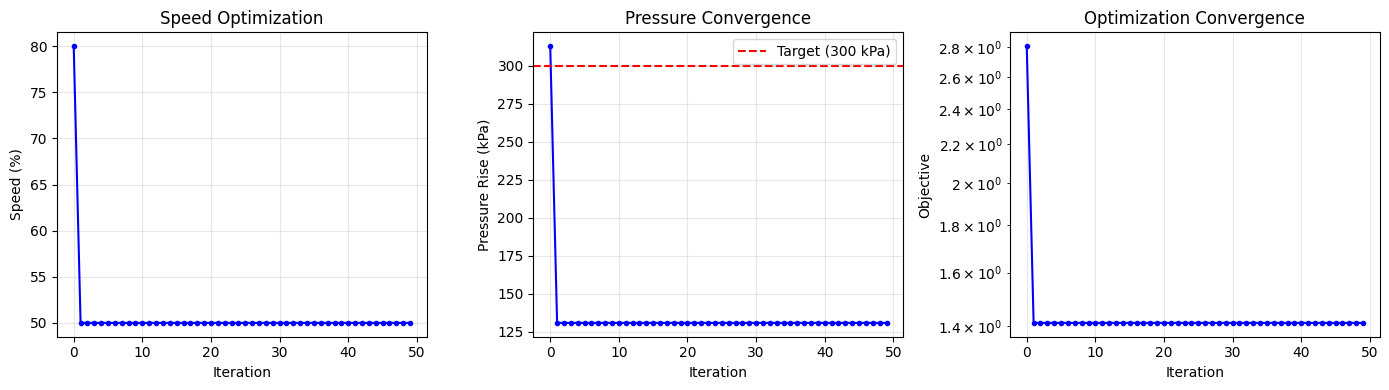

In [14]:
# Plot optimization progress
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

iterations = range(len(history))

axes[0].plot(iterations, [h['speed']*100 for h in history], 'b-o', markersize=3)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Speed (%)')
axes[0].set_title('Speed Optimization')
axes[0].grid(True, alpha=0.3)

axes[1].plot(iterations, [h['dP']/1000 for h in history], 'b-o', markersize=3)
axes[1].axhline(target_dP/1000, color='r', linestyle='--', label=f'Target ({target_dP/1000:.0f} kPa)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Pressure Rise (kPa)')
axes[1].set_title('Pressure Convergence')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].semilogy(iterations, [h['objective'] for h in history], 'b-o', markersize=3)
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Objective')
axes[2].set_title('Optimization Convergence')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Dynamic Optimization

Optimize pump startup trajectory to minimize energy while reaching target pressure quickly.

In [15]:
def dynamic_objective(omega_setpoint, inlet, target_P, t_final=5.0):
    """Objective for dynamic optimization.
    
    Minimize: settling time + integral of speed^3 (proxy for energy)
    Subject to: reach target pressure
    """
    # Create pump with given setpoint
    pump = DynamicSurrogatePump(
        nn_params=nn_params,
        input_scale=input_scale,
        output_scale=output_scale,
    )
    pump._params["omega_setpoint"] = omega_setpoint
    
    # Simulate
    result = integrate_unit(
        pump,
        inputs={"inlet": inlet},
        t_span=(0.0, t_final),
        method="RK4",
        n_steps=100,
    )
    
    # Terminal pressure error
    P_final = result.y_final[1]
    pressure_error = (P_final - target_P)**2 / target_P**2
    
    # Energy proxy: integral of omega^3 (power ~ omega^3)
    omega_traj = result.trajectory.y[:, 0]
    energy_proxy = jnp.mean(omega_traj**3) / (pump.omega_rated**3)
    
    return pressure_error * 10 + energy_proxy * 0.1


# Optimize omega setpoint
inlet = make_stream({'water': 50.0}, T=300.0, P=101325.0)
target_P = inlet['P'] + 350000.0  # Target discharge pressure

omega_sp = jnp.array(250.0)  # Initial guess
learning_rate = 50.0
dynamic_history = []

print("Optimizing pump speed setpoint...")
for i in range(30):
    obj_val = dynamic_objective(omega_sp, inlet, target_P)
    grad_val = grad(dynamic_objective)(omega_sp, inlet, target_P)
    
    dynamic_history.append({
        'omega_sp': float(omega_sp),
        'objective': float(obj_val),
    })
    
    omega_sp = omega_sp - learning_rate * grad_val
    omega_sp = jnp.clip(omega_sp, 100.0, 400.0)
    
    if i % 10 == 0:
        print(f"  Iter {i}: omega_sp={omega_sp:.1f} rad/s, obj={obj_val:.6f}")

print(f"\nOptimal speed setpoint: {dynamic_history[-1]['omega_sp']:.1f} rad/s")

Optimizing pump speed setpoint...


  Iter 0: omega_sp=250.0 rad/s, obj=0.056513


  Iter 10: omega_sp=250.3 rad/s, obj=0.056317


  Iter 20: omega_sp=250.5 rad/s, obj=0.056271



Optimal speed setpoint: 250.5 rad/s


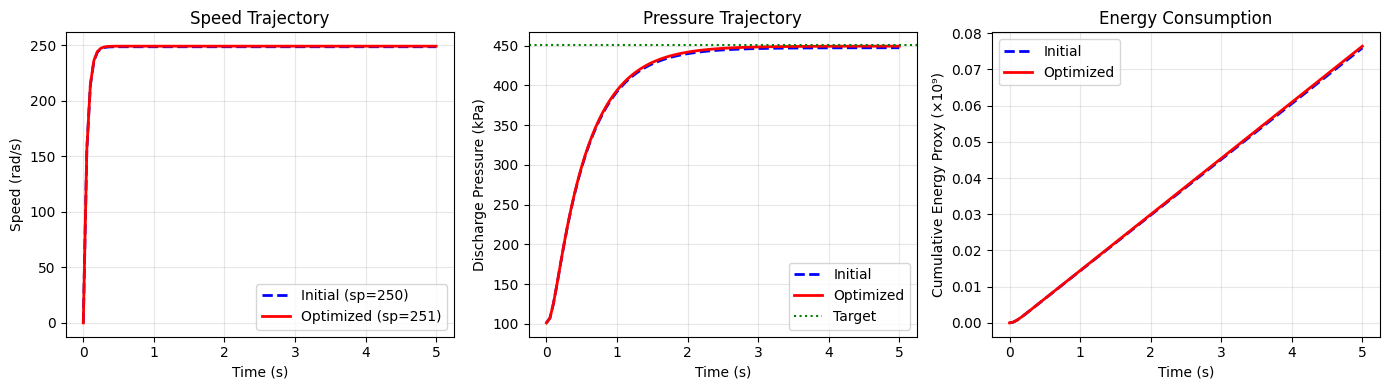

In [16]:
# Compare initial vs optimized trajectories
omega_initial = 250.0
omega_optimal = dynamic_history[-1]['omega_sp']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for omega_sp, label, style in [(omega_initial, 'Initial', 'b--'), (omega_optimal, 'Optimized', 'r-')]:
    pump = DynamicSurrogatePump(
        nn_params=nn_params,
        input_scale=input_scale,
        output_scale=output_scale,
    )
    pump._params["omega_setpoint"] = omega_sp
    
    result = integrate_unit(
        pump,
        inputs={"inlet": inlet},
        t_span=(0.0, 5.0),
        method="RK4",
        n_steps=100,
    )
    
    axes[0].plot(result.trajectory.t, result.trajectory.y[:, 0], style, 
                 label=f'{label} (sp={omega_sp:.0f})', linewidth=2)
    axes[1].plot(result.trajectory.t, result.trajectory.y[:, 1]/1000, style, 
                 label=label, linewidth=2)
    
    # Energy proxy
    energy = jnp.cumsum(result.trajectory.y[:, 0]**3) * (5.0/100)
    axes[2].plot(result.trajectory.t, energy / 1e9, style, label=label, linewidth=2)

axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Speed (rad/s)')
axes[0].set_title('Speed Trajectory')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].axhline(target_P/1000, color='g', linestyle=':', label='Target')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Discharge Pressure (kPa)')
axes[1].set_title('Pressure Trajectory')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Cumulative Energy Proxy (×10⁹)')
axes[2].set_title('Energy Consumption')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Using Surrogate in a Flowsheet

Finally, let's demonstrate using the static surrogate pump within a flowsheet.

In [17]:
from difflow import Flowsheet, Unit

# Create a simple flowsheet: Feed → Pump → Heater → Product

# Wrap surrogate pump for flowsheet interface
def pump_operation(inlet, speed_fraction=1.0):
    """Wrapper for surrogate pump in flowsheet."""
    return surrogate_pump(inlet, speed_fraction=speed_fraction)


# Create heater (needs thermo for enthalpy calculations)
# For simplicity, we'll create a minimal heater that just adds heat
def simple_heater(inlet, T_out=350.0):
    """Simple heater that sets outlet temperature."""
    outlet_flows = get_flows(inlet)
    outlet = make_stream(outlet_flows, T_out, inlet['P'])
    
    # Estimate duty
    Cp = 75.0  # J/mol/K
    F_total = total_flow(inlet)
    Q = F_total * Cp * (T_out - inlet['T'])
    
    return outlet, {'Q': Q, 'T_out': T_out}


# Build flowsheet
fs = Flowsheet(species_order=['water'])

# Add feed
feed = make_stream({'water': 50.0}, T=290.0, P=101325.0)
fs.add_feed('feed', feed)

# Add pump
fs.add_unit(Unit(
    name='pump',
    operation=pump_operation,
    inlet_names=['feed'],
    outlet_names=['pumped'],
    params={'speed_fraction': 0.9},
))

# Add heater
fs.add_unit(Unit(
    name='heater',
    operation=simple_heater,
    inlet_names=['pumped'],
    outlet_names=['product'],
    params={'T_out': 350.0},
))

# Solve flowsheet
streams = fs.solve()

# Get unit info by re-running the operations on the solved streams
_, pump_info = surrogate_pump(streams['feed'], speed_fraction=0.9)
_, heater_info = simple_heater(streams['pumped'], T_out=350.0)

print("Flowsheet Results:")
print(f"\nFeed:")
print(f"  F = {total_flow(streams['feed']):.1f} mol/s")
print(f"  T = {streams['feed']['T']:.1f} K")
print(f"  P = {streams['feed']['P']/1000:.1f} kPa")

print(f"\nAfter Pump:")
print(f"  F = {total_flow(streams['pumped']):.1f} mol/s")
print(f"  T = {streams['pumped']['T']:.2f} K")
print(f"  P = {streams['pumped']['P']/1000:.1f} kPa")
print(f"  Power = {pump_info['power']/1000:.2f} kW")

print(f"\nProduct:")
print(f"  F = {total_flow(streams['product']):.1f} mol/s")
print(f"  T = {streams['product']['T']:.1f} K")
print(f"  P = {streams['product']['P']/1000:.1f} kPa")
print(f"  Heater duty = {heater_info['Q']/1000:.2f} kW")

Flowsheet Results:

Feed:
  F = 50.0 mol/s
  T = 290.0 K
  P = 101.3 kPa

After Pump:
  F = 50.0 mol/s
  T = 290.88 K
  P = 506.7 kPa
  Power = 3.63 kW

Product:
  F = 50.0 mol/s
  T = 350.0 K
  P = 506.7 kPa
  Heater duty = 221.69 kW


### Flowsheet Optimization with Surrogate

In [18]:
def flowsheet_cost(speed_fraction, T_heater, feed):
    """Total operating cost: pump power + heater duty."""
    # Pump
    pumped, pump_info = surrogate_pump(feed, speed_fraction=speed_fraction)
    
    # Heater
    product, heater_info = simple_heater(pumped, T_out=T_heater)
    
    # Cost: electricity for pump ($0.10/kWh) + steam for heater ($0.02/kWh)
    pump_cost = pump_info['power'] / 1000 * 0.10  # $/h
    heater_cost = jnp.maximum(heater_info['Q'], 0.0) / 1000 * 0.02  # $/h
    
    # Constraint: final pressure must be > 300 kPa
    pressure_penalty = jnp.maximum(300000.0 - pumped['P'], 0.0)**2 / 1e10
    
    return pump_cost + heater_cost + pressure_penalty


# Optimize pump speed and heater temperature
feed = make_stream({'water': 50.0}, T=290.0, P=101325.0)

# Use manual gradient descent (could use scipy.optimize with JAX gradients)
speed = jnp.array(0.9)
T_heat = jnp.array(350.0)
lr_speed, lr_T = 0.1, 10.0

print("Optimizing flowsheet...")
for i in range(50):
    cost = flowsheet_cost(speed, T_heat, feed)
    grad_speed = grad(flowsheet_cost, argnums=0)(speed, T_heat, feed)
    grad_T = grad(flowsheet_cost, argnums=1)(speed, T_heat, feed)
    
    speed = jnp.clip(speed - lr_speed * grad_speed, 0.5, 1.0)
    T_heat = jnp.clip(T_heat - lr_T * grad_T, 300.0, 400.0)
    
    if i % 10 == 0:
        print(f"  Iter {i}: speed={speed*100:.1f}%, T_heat={T_heat:.1f} K, cost=${cost:.4f}/h")

print(f"\nOptimal: speed={speed*100:.1f}%, T_heater={T_heat:.1f} K")
print(f"Minimum cost: ${flowsheet_cost(speed, T_heat, feed):.4f}/h")

Optimizing flowsheet...
  Iter 0: speed=83.7%, T_heat=349.2 K, cost=$4.7967/h


  Iter 10: speed=85.4%, T_heat=341.8 K, cost=$4.1503/h
  Iter 20: speed=58.9%, T_heat=334.2 K, cost=$3.5430/h


  Iter 30: speed=68.3%, T_heat=326.8 K, cost=$3.0160/h
  Iter 40: speed=67.7%, T_heat=319.2 K, cost=$2.4514/h

Optimal: speed=77.0%, T_heater=312.5 K


Minimum cost: $1.9083/h


## Summary

This notebook demonstrated:

1. **Physics-based pump model** as ground truth for generating training data

2. **Static surrogate pump** using a neural network to predict:
   - Pressure rise
   - Temperature rise  
   - Power consumption

3. **Training the surrogate** with MSE loss and mini-batch SGD

4. **Dynamic surrogate pump** implementing `DynamicUnitBase` with:
   - Rotational speed dynamics (motor inertia)
   - Pressure dynamics (first-order lag)
   - NN-based steady-state prediction

5. **Gradient-based optimization** through both static and dynamic surrogates

6. **Flowsheet integration** showing surrogates work seamlessly with difflow

### Key Takeaways

- Surrogates follow the same interface as physics models: `outlet, info = unit(inlet, **params)`
- Full JAX differentiability enables gradient-based optimization
- Dynamic surrogates combine NN steady-state predictions with physics-based dynamics
- Training data can come from detailed models, experiments, or process simulators